## Librerias

In [1]:
try:
    import pandas as pd
except ImportError:
    print("Pandas not installed")
    %pip install pandas --user

try:
    import matplotlib.pyplot as plt
except ImportError:
    print("Matplotlib not installed")
    %pip install matplotlib --user

import ssl

ssl._create_default_https_context = ssl._create_unverified_context

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## Lectura de datos

- [Dataset Qatar 2022: https://www.kaggle.com/datasets/shrikrishnaparab/fifa-world-cup-2022-qatar-match-data](https://www.kaggle.com/datasets/shrikrishnaparab/fifa-world-cup-2022-qatar-match-data)

In [3]:
archivo = "https://raw.githubusercontent.com/IgnacioPardo/Tecnologias_Exponenciales_2025/refs/heads/main/qatar.csv"

# Leer datos del archivo
mundial : pd.DataFrame = pd.read_csv(archivo)
mundial

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
0,1,Sun,20-Nov-22,17:00,Al Bayt Stadium,Daniele Orsato,Group A,QATAR,ECUADOR,67372,...,0,1,6,5,0,0,52,72,256,279
1,2,Mon,21-Nov-22,14:00,Khalifa International Stadium,Raphael Claus,Group B,ENGLAND,IRAN,45334,...,0,1,8,13,0,0,63,72,139,416
2,3,Mon,21-Nov-22,17:00,Al Thumama Stadium,Wilton Sampaio,Group A,SENEGAL,NETHERLANDS,41721,...,0,0,9,15,0,0,63,73,263,251
3,4,Mon,21-Nov-22,20:00,Ahmed bin Ali Stadium,Abdulrahman Ibrahim Al Jassim,Group B,UNITED STATES,WALES,43418,...,0,1,7,7,0,0,81,72,242,292
4,5,Tue,22-Nov-22,11:00,Lusail Iconic Stadium,Slavko Vincic,Group C,ARGENTINA,SAUDI ARABIA,88012,...,1,0,4,14,0,0,65,80,163,361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,60,Sat,10-Dec-22,20:00,Al Bayt Stadium,Wilton Sampaio,Quarter-final,ENGLAND,FRANCE,68895,...,1,0,9,15,0,0,49,54,193,308
60,61,Tue,13-Dec-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Semi-Final,ARGENTINA,CROATIA,88966,...,1,0,12,10,0,0,85,63,321,260
61,62,Wed,14-Dec-22,20:00,Al Bayt Stadium,Cesar Ramos,Semi-Final,FRANCE,MOROCCO,68294,...,0,0,13,14,0,0,72,47,328,218
62,63,Sat,17-Dec-22,16:00,Khalifa International Stadium,Abdulrahman Ibrahim Al Jassim,Play-off for third place,CROATIA,MOROCCO,44137,...,0,0,7,14,0,0,75,72,288,277


In [9]:
# Cuantos partidos se jugaron?
# Completar
print("se jugaron "+str(mundial.shape[0])+" partidos")

se jugaron 64 partidos


In [12]:
# Que datos tiene el dataset? (Pista: usar .info(), .describe(), .columns, .head())
# Checkear columnas
# Completar
mundial.columns

Index(['match_no', 'day_of_week', 'date', 'hour', 'venue', 'referee', 'group',
       '1', '2', 'attendance', '1_xg', '2_xg', '1_poss', '2_poss', '1_goals',
       '2_goals', 'score', '1_attempts', '2_attempts', '1_conceded',
       '2_conceded', '1_goal_inside_penalty_area',
       '2_goal_inside_penalty_area', '1_goal_outside_penalty_area',
       '2_goal_outside_penalty_area', '1_ontarget', '2_ontarget',
       '1_offtarget', '2_offtarget', '1_attempts_inside_penalty_area',
       '2_attempts_inside_penalty_area', '1_attempts_outside_penalty_area',
       '2_attempts_outside_penalty_area', '1_yellow_cards', '2_yellow_cards',
       '1_red_cards', '2_red_cards', 'faul_against_1', 'faul_against_2',
       '1_offsides', '2_offsides', '1_passes', '2_passes',
       '1_passes_compeletd', '2_passes_compeletd', '1_corners', '2_corners',
       '1_free_kicks', '2_free_kicks', '1_panelties_scored',
       '2_panelties_scored', '1_goal_prevented', '2_goal_prevented',
       '1_own_goal', '2_o

## Analisis

### Primera Parte

In [13]:
# Cuantas selecciones participaron?
# Completar
mundial['1'].nunique()

32

In [16]:
# Cuantas fases tiene el mundial?
# Completar
mundial['group'].nunique()

13

In [17]:
# Cual fue la "attendance" promedio por partido?
# Completar
mundial['attendance'].mean()

np.float64(53191.4375)

In [28]:
# Cual fue el partido con mas diferencia de goles?
# Completar
mundial[['1','2','1_goals','2_goals']].loc[abs((mundial['1_goals']-mundial['2_goals'])).idxmax()]

,10
1,SPAIN
2,COSTA RICA
1_goals,7
2_goals,0


In [39]:
# Cual es la selección que mas penales metió?
# Completar
(mundial.groupby('1')['1_panelties_scored'].sum() + mundial.groupby('2')['2_panelties_scored'].sum()).idxmax()

'ARGENTINA'

In [43]:
# Cual es la selección que mas penales le hicieron?
# Completar
(mundial.groupby('2')['1_panelties_scored'].sum() + mundial.groupby('1')['2_panelties_scored'].sum()).idxmax()


'FRANCE'

### Segunda Parte

In [46]:
equipo : str = "ARGENTINA"

In [55]:
# Seleccionar todos los partidos que jugo el equipo de "local"
# Completar

filtroLocal : pd.Series = mundial[mundial['1'] == equipo]
filtroLocal

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
4,5,Tue,22-Nov-22,11:00,Lusail Iconic Stadium,Slavko Vincic,Group C,ARGENTINA,SAUDI ARABIA,88012,...,1,0,4,14,0,0,65,80,163,361
23,24,Sat,26-Nov-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Group C,ARGENTINA,MEXICO,88966,...,0,0,4,5,0,0,63,79,220,327
49,50,Sat,3-Dec-22,20:00,Ahmed bin Ali Stadium,Szymon Marciniak,Round of 16,ARGENTINA,AUSTRALIA,45032,...,0,0,5,14,1,0,67,73,240,453
60,61,Tue,13-Dec-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Semi-Final,ARGENTINA,CROATIA,88966,...,1,0,12,10,0,0,85,63,321,260
63,64,Sun,18-Dec-22,16:00,Lusail Iconic Stadium,Szymon Marciniak,Final,ARGENTINA,FRANCE,88966,...,1,2,11,21,0,0,87,104,280,409


In [56]:
# Seleccionar todos los partidos que jugo el equipo de "visitante"
# Completar

filtroVisitante : pd.Series = mundial[mundial["2"] == equipo]
filtroVisitante

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
38,39,Wed,30-Nov-22,20:00,Lusail Iconic Stadium,Michael Oliver,Group C,POLAND,ARGENTINA,84985,...,0,0,25,4,0,0,67,48,438,141
57,58,Fri,9-Dec-22,20:00,Lusail Iconic Stadium,Antonio Mateu Lahoz,Quarter-final,NETHERLANDS,ARGENTINA,88235,...,0,1,15,5,0,0,91,79,401,323


In [58]:
# Seleccionar todos los partidos que jugo el equipo (de "local" o "visitante")
# Completar

partidos : pd.DataFrame = mundial[(mundial["1"] == equipo) | (mundial["2"] == equipo)]
partidos


,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
4,5,Tue,22-Nov-22,11:00,Lusail Iconic Stadium,Slavko Vincic,Group C,ARGENTINA,SAUDI ARABIA,88012,...,1,0,4,14,0,0,65,80,163,361
23,24,Sat,26-Nov-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Group C,ARGENTINA,MEXICO,88966,...,0,0,4,5,0,0,63,79,220,327
38,39,Wed,30-Nov-22,20:00,Lusail Iconic Stadium,Michael Oliver,Group C,POLAND,ARGENTINA,84985,...,0,0,25,4,0,0,67,48,438,141
49,50,Sat,3-Dec-22,20:00,Ahmed bin Ali Stadium,Szymon Marciniak,Round of 16,ARGENTINA,AUSTRALIA,45032,...,0,0,5,14,1,0,67,73,240,453
57,58,Fri,9-Dec-22,20:00,Lusail Iconic Stadium,Antonio Mateu Lahoz,Quarter-final,NETHERLANDS,ARGENTINA,88235,...,0,1,15,5,0,0,91,79,401,323
60,61,Tue,13-Dec-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Semi-Final,ARGENTINA,CROATIA,88966,...,1,0,12,10,0,0,85,63,321,260
63,64,Sun,18-Dec-22,16:00,Lusail Iconic Stadium,Szymon Marciniak,Final,ARGENTINA,FRANCE,88966,...,1,2,11,21,0,0,87,104,280,409


In [69]:
# Cuantos goles hizo el equipo en total (obtener los goles metidos de local y sumarlos con los goles metidos de visitante)
# Completar

goles : int = ((partidos[partidos["1"]==equipo]['1_goals']).sum() + (partidos[partidos["2"]==equipo]['2_goals']).sum())
goles

np.int64(15)

In [70]:
# Cuantos goles hizo el equipo en promedio
# Completar
goles / partidos.shape[0]

np.float64(2.142857142857143)

In [78]:
# Cuantos partidos gano el equipo
# Completar

ganados : int = partidos[((partidos["1"] == equipo) & (partidos['1_goals']>partidos["2_goals"]))
 |
 ((partidos["2"] == equipo) & (partidos['2_goals']>partidos["1_goals"]))].shape[0]
ganados

4

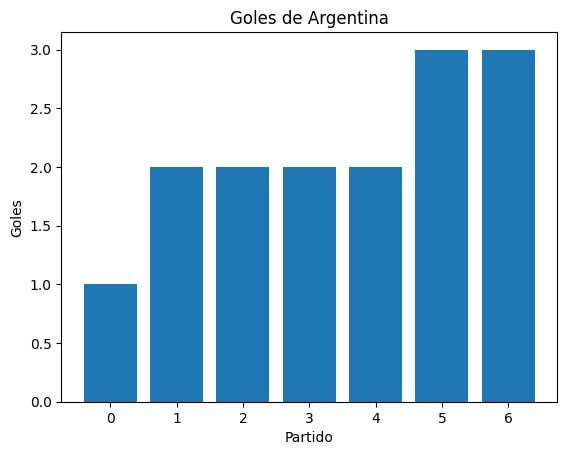

In [136]:
# Graficar los goles hechos por el equipo en cada partido

fig, ax = plt.subplots()

goles = []
for i in range(mundial.shape[0]):
    if mundial.iloc[i]['1'] == equipo:
        goles.append(mundial.iloc[i]['1_goals'])
    elif mundial.iloc[i]['2'] == equipo:
        goles.append(mundial.iloc[i]['2_goals'])

ax.bar(range(len(goles)), goles)
ax.set_title("Goles de Argentina")
ax.set_xlabel("Partido")
ax.set_ylabel("Goles")
plt.show()
# Completar

### Tercera Parte

In [92]:
# Contar cuantos goles hizo cada equipo en total en el mundial
# Completar
goles:int = mundial["1_goals"].groupby(mundial["1"]).sum() + mundial["2_goals"].groupby(mundial["2"]).sum()
goles.sort_values(ascending=False)

,0
1,
FRANCE,16
ARGENTINA,15
ENGLAND,13
PORTUGAL,12
NETHERLANDS,10
SPAIN,9
CROATIA,8
BRAZIL,8
MOROCCO,6


In [ ]:
# Graficar los goles por equipo en todo el mundial

fig, ax = plt.subplots()
# Completar

In [98]:
# Cual es el equipo que hizo mas goles en el mundial?
# Completar
goles[goles == goles.max()]

,0
1,
FRANCE,16


In [112]:
# Por cada partido, cual fue la diferencia de goles?
# Completar
diferencia = (mundial['1_goals']-mundial['2_goals'])
mundial[['1', '2']].assign(diferencia=diferencia)

,1,2,diferencia
0,QATAR,ECUADOR,-2
1,ENGLAND,IRAN,4
2,SENEGAL,NETHERLANDS,-2
3,UNITED STATES,WALES,0
4,ARGENTINA,SAUDI ARABIA,-1
...,...,...,...
59,ENGLAND,FRANCE,-1
60,ARGENTINA,CROATIA,3
61,FRANCE,MOROCCO,2
62,CROATIA,MOROCCO,1


In [120]:
ganadores =[]
for i in range(mundial.shape[0]):
  if(mundial.iloc[i]['1_goals'] > mundial.iloc[i]['2_goals']):
    ganadores.append(mundial.iloc[i]['1'])
  elif (mundial.iloc[i]['1_goals'] < mundial.iloc[i]['2_goals']):
      ganadores.append(mundial.iloc[i]['2'])
  else:
      ganadores.append("EMPATE")
mundial["ganadores"] = ganadores
mundial[["1", "2", "ganadores"]]

,1,2,ganadores
0,QATAR,ECUADOR,ECUADOR
1,ENGLAND,IRAN,ENGLAND
2,SENEGAL,NETHERLANDS,NETHERLANDS
3,UNITED STATES,WALES,EMPATE
4,ARGENTINA,SAUDI ARABIA,SAUDI ARABIA
...,...,...,...
59,ENGLAND,FRANCE,FRANCE
60,ARGENTINA,CROATIA,ARGENTINA
61,FRANCE,MOROCCO,FRANCE
62,CROATIA,MOROCCO,CROATIA


In [133]:
# En cada fase del mundial, cual fue el equipo que hizo mas goles?
# Completar
goles_1 = mundial[['group', '1', '1_goals']].rename(columns={'1': 'equipo', '1_goals': 'goles'})
goles_2 = mundial[['group', '2', '2_goals']].rename(columns={'2': 'equipo', '2_goals': 'goles'})

pd.concat([goles_1, goles_2]).groupby(['group', 'equipo'])['goles'].sum().groupby('group').idxmax()

,goles
group,
Final,"(Final, ARGENTINA)"
Group A,"(Group A, NETHERLANDS)"
Group B,"(Group B, ENGLAND)"
Group C,"(Group C, ARGENTINA)"
Group D,"(Group D, FRANCE)"
Group E,"(Group E, SPAIN)"
Group F,"(Group F, CROATIA)"
Group G,"(Group G, SERBIA)"
Group H,"(Group H, PORTUGAL)"


### Tercera Parte

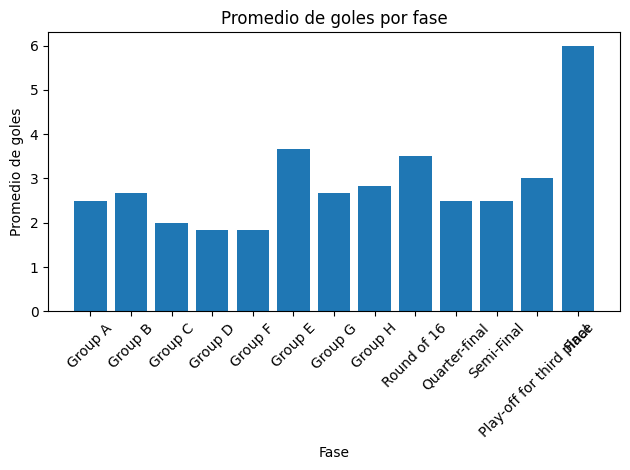

In [137]:
# Armar un gráfico a partir de algun nuevo análisis que se te ocurra
# Completar
fases = []
promedios = []

for i in range(mundial.shape[0]):
    if mundial.iloc[i]['group'] not in fases:
        fases.append(mundial.iloc[i]['group'])

for fase in fases:
    total_goles = 0
    partidos = 0
    for i in range(mundial.shape[0]):
        if mundial.iloc[i]['group'] == fase:
            total_goles += mundial.iloc[i]['1_goals'] + mundial.iloc[i]['2_goals']
            partidos += 1
    promedios.append(total_goles / partidos)

fig, ax = plt.subplots()
ax.bar(fases, promedios)
ax.set_title("Promedio de goles por fase")
ax.set_xlabel("Fase")
ax.set_ylabel("Promedio de goles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()